## TextFooler (Jin et al. 2019) Statistical Tests
The code below performs parametric and non-parametric statistical tests to determine whether layer-wise Wasserstein distances have significantly different means. We create violin plots and heatmaps to show the differences in log-Wasserstein distance distributions between layers, and their corresponding p-values.

### Config and Imports

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal, f_oneway
import scikit_posthocs as sp
import statsmodels.stats.multicomp as mc
import matplotlib.pyplot as plt
import seaborn as sns

### Statistical Tests and Plotting

Layer-wise ANOVA F = 51.9244, p = 7.6177e-105


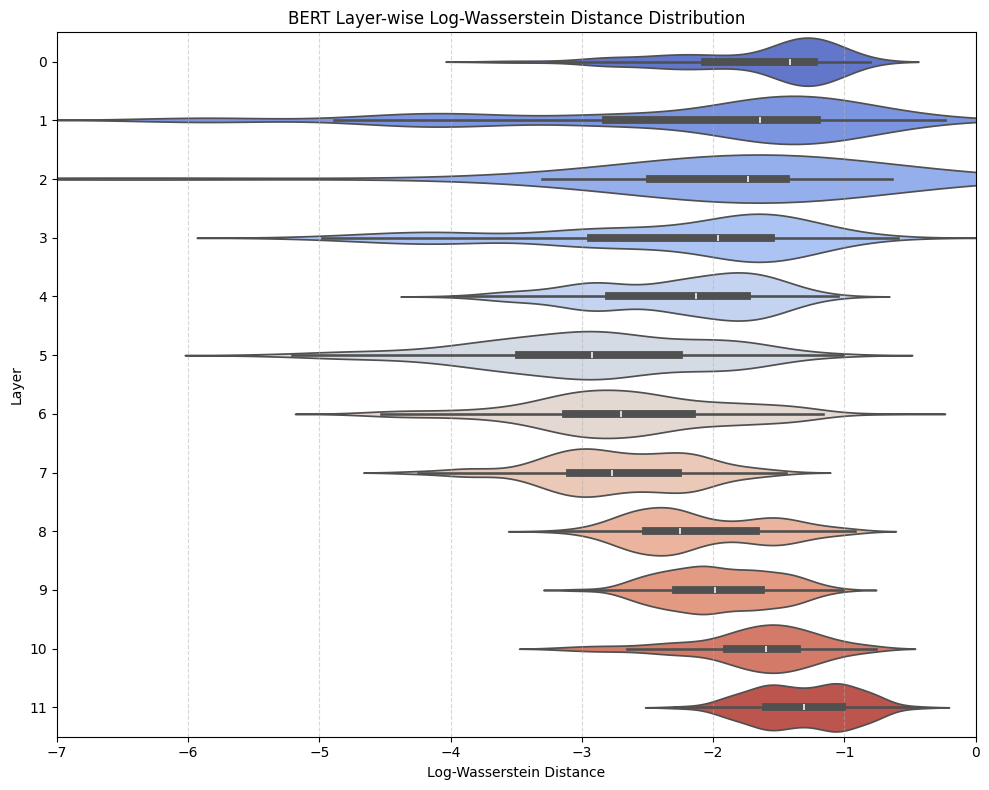

BERT Layer-wise Kruskal-Wallis H = 901.9977, p = 2.3066e-186


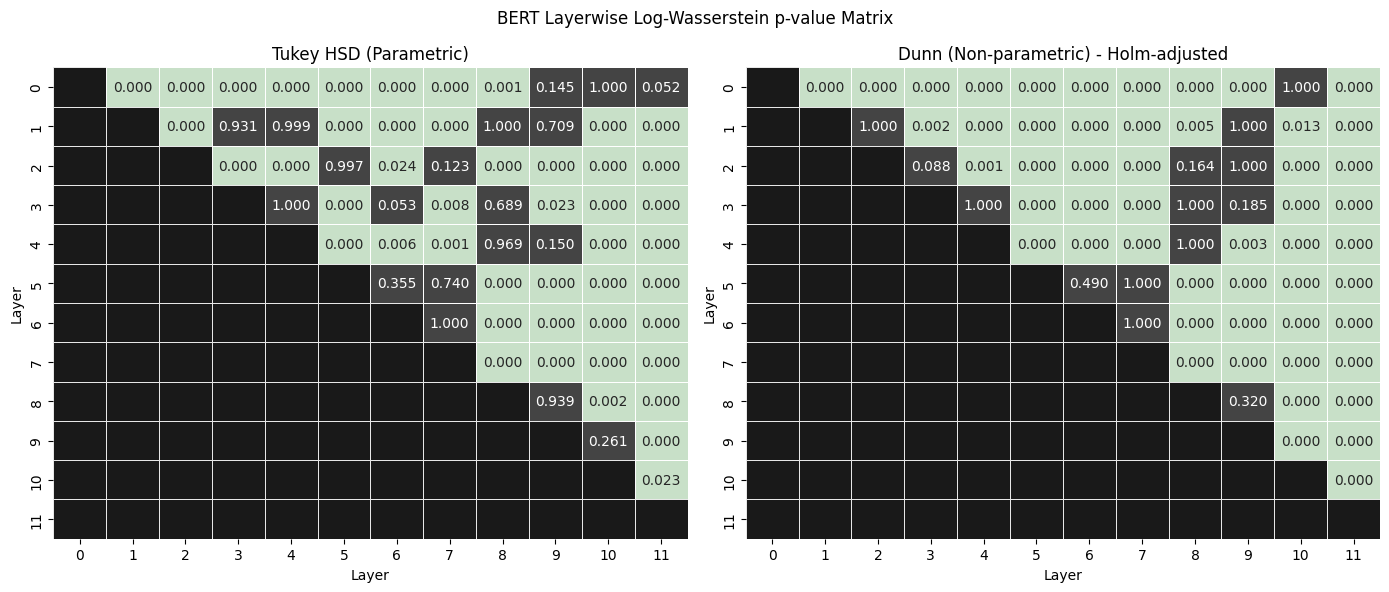

Layer-wise ANOVA F = 32.9161, p = 1.5156e-66


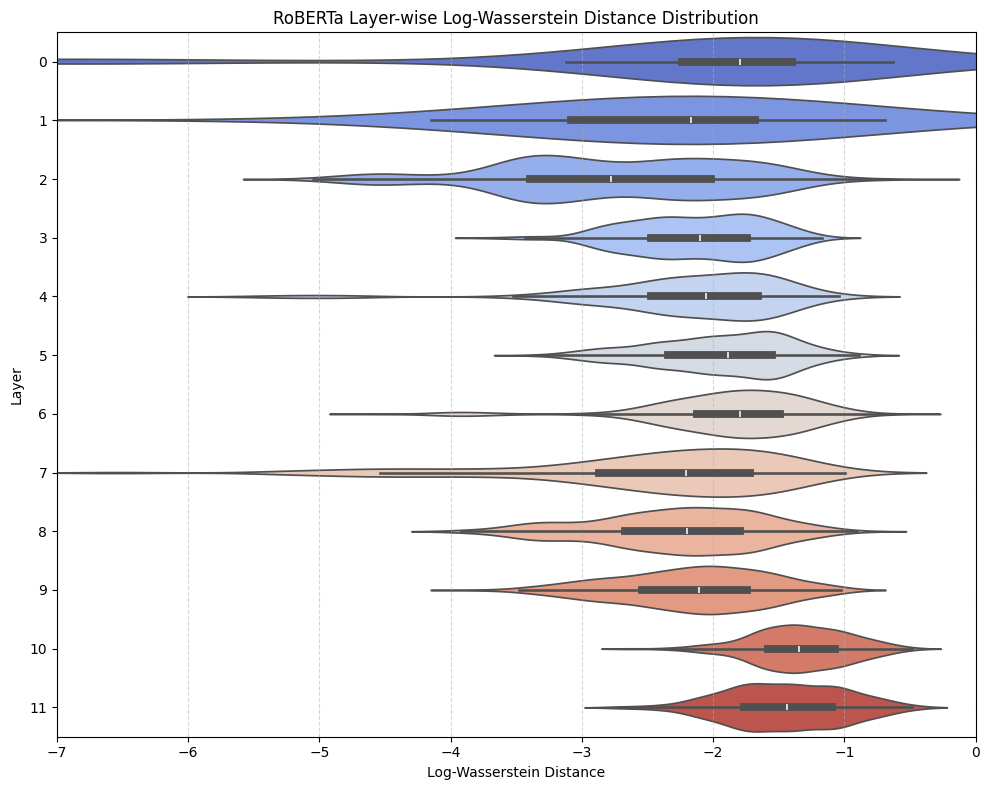

RoBERTa Layer-wise Kruskal-Wallis H = 753.4060, p = 1.8980e-154


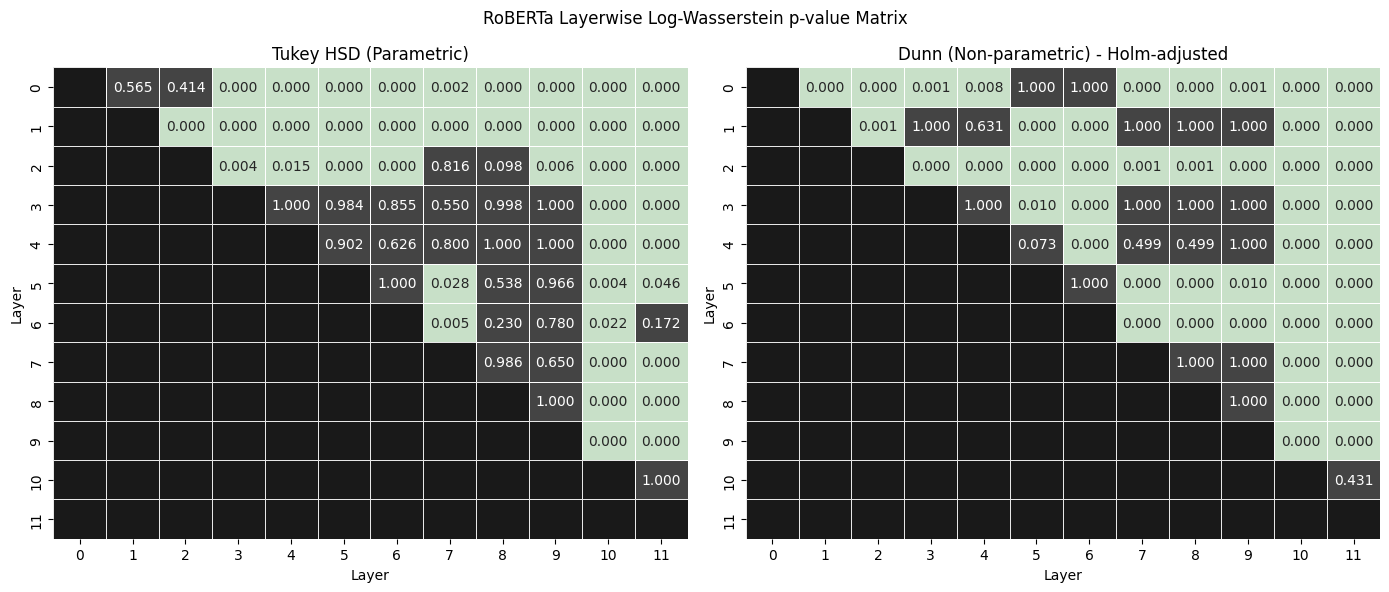

Layer-wise ANOVA F = 50.1853, p = 5.1589e-48


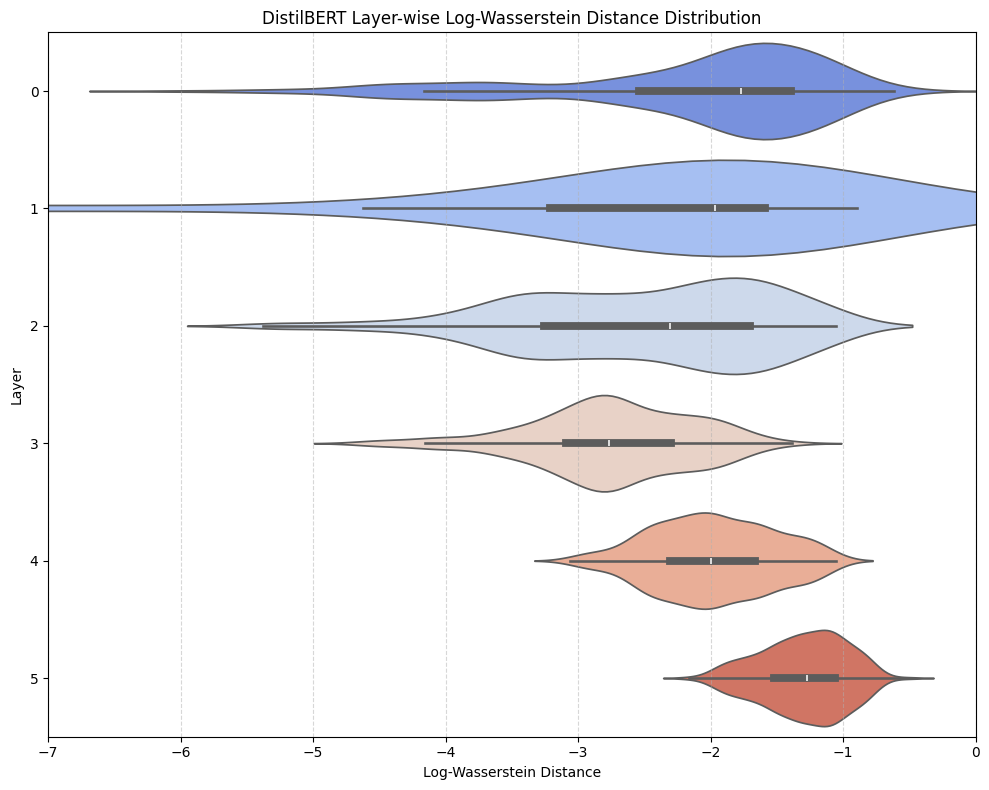

DistilBERT Layer-wise Kruskal-Wallis H = 493.8799, p = 1.6720e-104


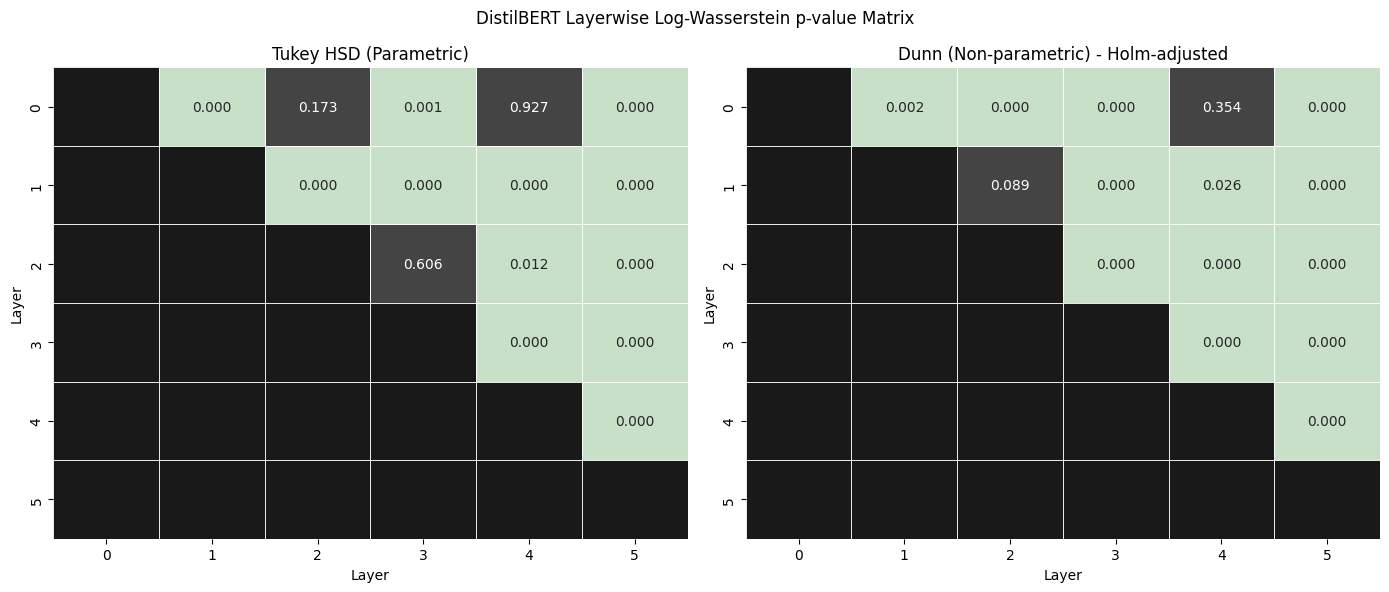

In [55]:
stylized_names = {
    "bert": "BERT",
    "roberta": "RoBERTa",
    "distilbert": "DistilBERT"
}

for model_name in ["bert", "roberta", "distilbert"]:
    Ws = np.load(f"./visualizations_new/{model_name}/top_20_batch_wasserstein_matrix.npy")
    # Perform ANOVA
    groups = [np.log10(Ws[:, layer, :].flatten()) for layer in range(Ws.shape[1])]

    F_stat, p_value = f_oneway(*groups)
    print(f"Layer-wise ANOVA F = {F_stat:.4f}, p = {p_value:.4e}")

    # Flatten data and create group labels
    vals = np.concatenate(groups)
    labels = np.concatenate([[f'{i}']*len(g) for i, g in enumerate(groups)])

    comp = mc.MultiComparison(vals, labels)
    tukey_result = comp.tukeyhsd()

    # Plot violin
    plt.figure(figsize=(10, 8))
    sns.violinplot(data=groups, orient='h', palette="coolwarm", bw_adjust=0.9, width=0.82)
    plt.yticks(ticks=np.arange(Ws.shape[1]), labels=[f'{i}' for i in range(Ws.shape[1])])
    plt.xlim(-7, 0)
    plt.xlabel('Log-Wasserstein Distance')
    plt.ylabel('Layer')
    plt.title(f'{stylized_names[model_name]} Layer-wise Log-Wasserstein Distance Distribution')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save figure
    violin_save_path = f"./visualizations_new/{model_name}/top_20_wasserstein_violin_plot.png"
    os.makedirs(os.path.dirname(violin_save_path), exist_ok=True)
    plt.savefig(violin_save_path, dpi=300)
    plt.show()

    # Kruskal-Wallis
    H_stat, p_value = kruskal(*groups)
    print(f"{stylized_names[model_name]} Layer-wise Kruskal-Wallis H = {H_stat:.4f}, p = {p_value:.4e}")

    if p_value < 0.05:
        # -------------------------
        # Build Tukey matrix
        # -------------------------
        n_layers = len(groups)
        tukey_p = np.ones((n_layers, n_layers))

        for row in tukey_result._results_table.data[1:]:
            i, j = int(row[0]), int(row[1])
            p = float(row[3])
            tukey_p[i, j] = p
            tukey_p[j, i] = p

        # -------------------------
        # Dunn matrix
        # -------------------------
        dunn_p = sp.posthoc_dunn(groups, p_adjust='holm').values

        # -------------------------
        # Common settings
        # -------------------------
        mask_upper = np.tril(np.ones((n_layers, n_layers), dtype=bool))
        from matplotlib.colors import ListedColormap
        cmap = ListedColormap(["#444444", "#c8e0c8"])

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # -------------------------
        # Tukey heatmap
        # -------------------------
        sns.heatmap(
            (tukey_p < 0.05).astype(int),
            annot=np.round(tukey_p, 3),
            fmt=".3f",
            cmap=cmap,
            mask=mask_upper,
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            ax=axes[0]
        )
        sns.heatmap(
            np.zeros_like(tukey_p),
            mask=~mask_upper,
            cmap=ListedColormap(["black"]),
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            alpha=0.9,
            ax=axes[0]
        )
        axes[0].set_title("Tukey HSD (Parametric)")
        axes[0].set_xlabel("Layer")
        axes[0].set_ylabel("Layer")

        # -------------------------
        # Dunn heatmap
        # -------------------------
        sns.heatmap(
            (dunn_p < 0.05).astype(int),
            annot=np.round(dunn_p, 3),
            fmt=".3f",
            cmap=cmap,
            mask=mask_upper,
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            ax=axes[1]
        )
        sns.heatmap(
            np.zeros_like(dunn_p),
            mask=~mask_upper,
            cmap=ListedColormap(["black"]),
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            alpha=0.9,
            ax=axes[1]
        )
        axes[1].set_title("Dunn (Non-parametric) - Holm-adjusted")
        axes[1].set_xlabel("Layer")
        axes[1].set_ylabel("Layer")

        plt.suptitle(f"{stylized_names[model_name]} Layerwise Log-Wasserstein p-value Matrix")
        plt.tight_layout()
        # Save figure
        heatmap_save_path = f"./visualizations_new/{model_name}/top_20_wasserstein_pvalue_heatmaps.png"
        plt.savefig(heatmap_save_path, dpi=300)
        plt.show()